In [1]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [9]:
import cv2
import numpy as np
import os
import glob

# 1. Configuração dos caminhos (Ajuste para as suas pastas)
PASTA_ORIGINAL = "DIV2K_train_LR_x8"  # Onde estão suas fotos (ex: DIV2K ou BSDS500)
PASTA_RESULTADO = "resultado"                     # Onde vamos salvar os testes

# Criando as pastas de saída para organizar o projeto
os.makedirs(os.path.join(PASTA_RESULTADO, "imagens_danificadas"), exist_ok=True)
os.makedirs(os.path.join(PASTA_RESULTADO, "mascaras"), exist_ok=True)

# 2. Buscar todas as imagens da pasta original (Formatos mais comuns)
formatos = ["*.jpg", "*.jpeg", "*.png", "*.bmp"]
arquivos_imagens = []
for f in formatos:
    arquivos_imagens.extend(glob.glob(os.path.join(PASTA_ORIGINAL, f)))

# Ordenar para garantir consistência e pegar as 10 primeiras
arquivos_imagens = sorted(arquivos_imagens)
imagens_selecionadas = arquivos_imagens[:10]

if not imagens_selecionadas:
    print(f"Nenhuma imagem encontrada em: {PASTA_ORIGINAL}. Verifique o caminho!")
    exit()

print(f"Encontradas {len(arquivos_imagens)} imagens. Processando as 10 primeiras...\n")

# 3. Loop para processar cada uma das 10 imagens
for i, caminho_img in enumerate(imagens_selecionadas):
    nome_arquivo = os.path.basename(caminho_img)
    
    # Carregar imagem real
    img = cv2.imread(caminho_img)
    if img is None:
        print(f"Erro ao carregar a imagem: {nome_arquivo}")
        continue
        
    altura, largura, canais = img.shape
    
    # Criar uma máscara em branco (tudo preto, tamanho igual ao da imagem)
    # 0 = pixel original / 255 = pixel que precisa de inpainting (restauração)
    mascara = np.zeros((altura, largura), dtype=np.uint8)
    
    # ---- GERANDO O DANO (MÁSCARA) ----
    # Vamos criar um quadrado centralizado correspondente a 15% do tamanho da imagem
    tamanho_quadrado = int(min(altura, largura) * 0.4)
    
    centro_y, centro_x = altura // 2, largura // 2
    y1 = centro_y - (tamanho_quadrado // 2)
    y2 = centro_y + (tamanho_quadrado // 2)
    x1 = centro_x - (tamanho_quadrado // 2)
    x2 = centro_x + (tamanho_quadrado // 2)
    
    # Desenhar o quadrado branco na MÁSCARA (indica onde o algoritmo vai atuar)
    mascara[y1:y2, x1:x2] = 255
    
    # Aplicar o dano na IMAGEM ORIGINAL (pintar de branco/apagado na imagem que o aluno verá)
    img_danificada = img.copy()
    img_danificada[y1:y2, x1:x2] = [255, 255, 255] # Cor branca simulando o buraco
    # ----------------------------------
    
    # 4. Salvar os resultados
    caminho_salvar_img = os.path.join(PASTA_RESULTADO, "imagens_danificadas", f"danificada_{nome_arquivo}")
    caminho_salvar_masc = os.path.join(PASTA_RESULTADO, "mascaras", f"mascara_{nome_arquivo}")
    
    cv2.imwrite(caminho_salvar_img, img_danificada)
    cv2.imwrite(caminho_salvar_masc, mascara)
    
    print(f"[{i+1}/10] Processada: {nome_arquivo} | Resolução: {largura}x{altura}")

print(f"\nSucesso! Verifique a pasta '{PASTA_RESULTADO}' para ver as imagens prontas.")

Encontradas 800 imagens. Processando as 10 primeiras...

[1/10] Processada: 0001x8.png | Resolução: 255x175
[2/10] Processada: 0002x8.png | Resolução: 255x231
[3/10] Processada: 0003x8.png | Resolução: 255x169
[4/10] Processada: 0004x8.png | Resolução: 255x168
[5/10] Processada: 0005x8.png | Resolução: 201x255
[6/10] Processada: 0006x8.png | Resolução: 169x255
[7/10] Processada: 0007x8.png | Resolução: 255x169
[8/10] Processada: 0008x8.png | Resolução: 255x169
[9/10] Processada: 0009x8.png | Resolução: 255x190
[10/10] Processada: 0010x8.png | Resolução: 255x205

Sucesso! Verifique a pasta 'resultado' para ver as imagens prontas.


Iniciando processamento em lote para 10 imagens utilizando Raio = 10...

[1/10] Computando Sistema Linear para: danificada_0001x8.png...


/tmp/ipykernel_199692/3666538839.py:90: SparseEfficiencyWarning: splu converted its input to CSC format
  fatoracao_lu = splu(A)


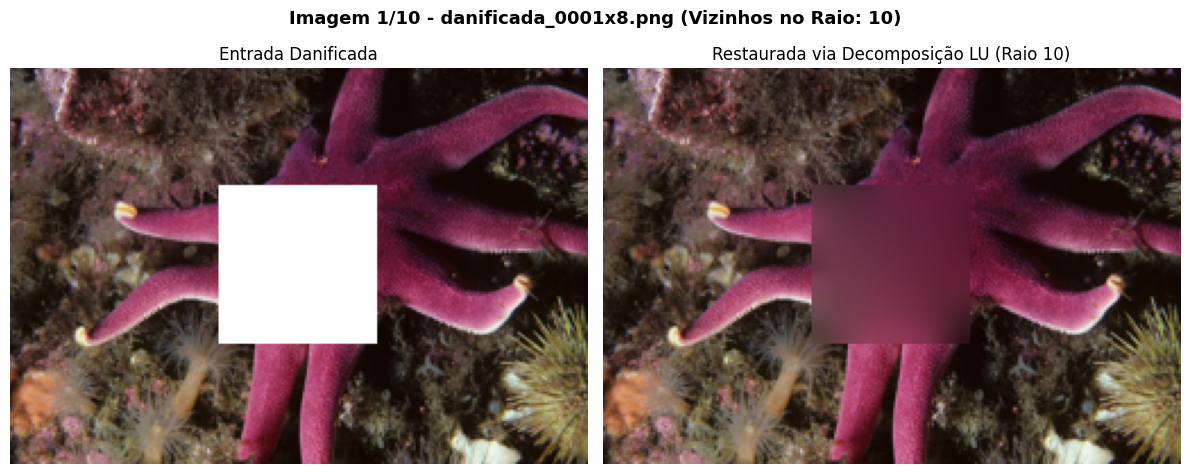

[2/10] Computando Sistema Linear para: danificada_0002x8.png...


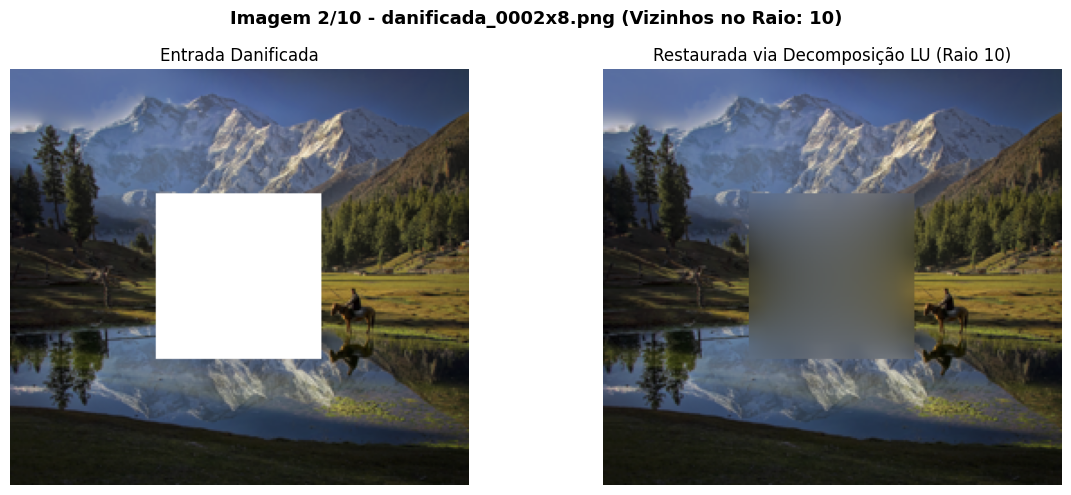

[3/10] Computando Sistema Linear para: danificada_0003x8.png...


KeyboardInterrupt: 

In [15]:
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import splu

# ==========================================
# 1. CONFIGURAÇÃO DE PASTAS CORRIGIDA
# ==========================================
PASTA_DATASET = "resultado"
PASTA_DANIFICADAS = os.path.join(PASTA_DATASET, "imagens_danificadas")
PASTA_MASCARAS = os.path.join(PASTA_DATASET, "mascaras")
PASTA_SAIDA = os.path.join(PASTA_DATASET, "imagens_restauradas")

os.makedirs(PASTA_SAIDA, exist_ok=True)

# Buscar os arquivos .png usando a sintaxe correta do glob
lista_danificadas = sorted(glob.glob(os.path.join(PASTA_DANIFICADAS, "*.png")))
lista_mascaras = sorted(glob.glob(os.path.join(PASTA_MASCARAS, "*.png")))

# Garantir que limitamos estritamente às 10 primeiras imagens do array
lista_danificadas = lista_danificadas[:10]
lista_mascaras = lista_mascaras[:10]

if not lista_danificadas or not lista_mascaras:
    print("Erro: Nenhuma imagem ou máscara encontrada. Verifique se os arquivos estão na pasta 'resultado'.")
    exit()

# ==========================================
# 2. FUNÇÃO DE RESTAURAÇÃO COM RAIO CONFIGURÁVEL
# ==========================================
def restaurar_canal_lu_raio_configuravel(img_canal, mascara, raio=2):
    """
    Resolve o sistema Ax=b expandindo a vizinhança matemática com base em um RAIO.
    raio=1: 8 vizinhos (bloco 3x3)
    raio=2: 24 vizinhos (bloco 5x5)
    raio=3: 48 vizinhos (bloco 7x7)
    """
    altura, largura = img_canal.shape
    
    # Mapear pixels desconhecidos (onde a máscara é branca / 255)
    pixels_brancos = np.where(mascara == 255)
    coordenadas_incognitas = list(zip(pixels_brancos[0], pixels_brancos[1]))
    
    mapeamento = {coord: idx for idx, coord in enumerate(coordenadas_incognitas)}
    N = len(mapeamento)
    
    if N == 0:
        return img_canal.copy()
    
    # Matriz A em formato LIL para montagem esparsa rápida
    A = lil_matrix((N, N), dtype=np.float32)
    b = np.zeros(N, dtype=np.float32)
    
    # Gerar a lista de deslocamentos com base no raio escolhido
    # Se raio=2, irá gerar deslocamentos de -2 até +2 em ambas as direções
    deslocamentos = []
    for di in range(-raio, raio + 1):
        for dj in range(-raio, raio + 1):
            if di == 0 and dj == 0:
                continue # Pula o próprio pixel central
            deslocamentos.append((di, dj))
            
    num_vizinhos = len(deslocamentos)
    
    # Montar a matriz esparsa
    for (i, j), id_atual in mapeamento.items():
        # O peso central passa a ser o negativo do número total de vizinhos encontrados no raio
        A[id_atual, id_atual] = -float(num_vizinhos)
        
        # Percorrer a janela de adjacentes definida pelo raio
        for di, dj in deslocamentos:
            vi, vj = i + di, j + dj
            
            # Validar se o vizinho expandido não está fora dos limites físicos da imagem
            if 0 <= vi < altura and 0 <= vj < largura:
                if mascara[vi, vj] == 255:
                    id_vizinho = mapeamento[(vi, vj)]
                    A[id_atual, id_vizinho] = 1.0
                else:
                    # Se o vizinho for um pixel conhecido, passa a intensidade de cor para b com sinal invertido
                    b[id_atual] -= float(img_canal[vi, vj])
                    
    # Converter para CSR (Compressed Sparse Row) antes de computar o solver matemático
    A = A.tocsr()
    
    # Resolver o sistema linear via Decomposição LU esparsa
    fatoracao_lu = splu(A)
    x = fatoracao_lu.solve(b)
    
    # Reconstruir a matriz da imagem aplicando os novos valores calculados
    img_corrigida = img_canal.copy()
    for (i, j), id_atual in mapeamento.items():
        img_corrigida[i, j] = np.clip(x[id_atual], 0, 255)
        
    return img_corrigida

# ==========================================
# 3. LOOP PRINCIPAL: PROCESSAR E PLOTAR AS 10 IMAGENS
# ==========================================
# --- DEFINA O RAIO AQUI ---
# Teste mudar este valor para 2 ou 3 para ver a diferença na coleta de adjacentes
RAIO_VIZINHANCA = 10
print(f"Iniciando processamento em lote para {len(lista_danificadas)} imagens utilizando Raio = {RAIO_VIZINHANCA}...\n")

for idx, (caminho_danificada, caminho_mascara) in enumerate(zip(lista_danificadas, lista_mascaras)):
    nome_base = os.path.basename(caminho_danificada)
    print(f"[{idx+1}/10] Computando Sistema Linear para: {nome_base}...")
    
    # Carregar imagem danificada (BGR) e a máscara (Grayscale)
    img_danificada = cv2.imread(caminho_danificada)
    mascara = cv2.imread(caminho_mascara, cv2.IMREAD_GRAYSCALE)
    
    # Separar em 3 canais (Azul, Verde, Vermelho) para tratar as matrizes de cor
    canais = cv2.split(img_danificada)
    canais_restaurados = []
    
    for canal in canais:
        # Executa a restauração informando o novo raio de adjacentes escolhido
        canal_corrigido = restaurar_canal_lu_raio_configuravel(canal, mascara, raio=RAIO_VIZINHANCA)
        canais_restaurados.append(canal_corrigido)
        
    # Unir os canais processados de volta em uma única imagem colorida
    img_restaurada = cv2.merge(canais_restaurados)
    
    # Salvar o arquivo final gerado em disco
    cv2.imwrite(os.path.join(PASTA_SAIDA, f"restaurada_raio{RAIO_VIZINHANCA}_{nome_base}"), img_restaurada)
    
    # ==========================================
    # 4. PLOTAR GRÁFICO LADO A LADO PARA CADA IMAGEM
    # ==========================================
    img_danificada_rgb = cv2.cvtColor(img_danificada, cv2.COLOR_BGR2RGB)
    img_restaurada_rgb = cv2.cvtColor(img_restaurada, cv2.COLOR_BGR2RGB)
    
    fig, eixos = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Imagem {idx+1}/10 - {nome_base} (Vizinhos no Raio: {RAIO_VIZINHANCA})", fontsize=13, fontweight='bold')
    
    eixos[0].imshow(img_danificada_rgb)
    eixos[0].set_title("Entrada Danificada")
    eixos[0].axis("off")
    
    eixos[1].imshow(img_restaurada_rgb)
    eixos[1].set_title(f"Restaurada via Decomposição LU (Raio {RAIO_VIZINHANCA})")
    eixos[1].axis("off")
    
    plt.tight_layout()
    plt.show()

print(f"\n[SUCESSO] Todas as 10 imagens foram processadas com Raio {RAIO_VIZINHANCA}!")